# Time-Series Foundation Model Forecasting Using Chronos

## Part 7 – Appliance Energy Forecasting with a Foundation Model

This notebook applies a pretrained time-series foundation model to forecast appliance energy consumption.

Unlike traditional forecasting approaches such as SARIMA/SARIMAX and machine learning models such as XGBoost, foundation models are pretrained on large collections of time-series data and can generate forecasts without task-specific training.

The Chronos-T5 model is used as a zero-shot forecasting model.

The objective is to forecast the next 24 hours of appliance energy consumption and compare the performance against previous models:

- Benchmark forecasting methods
- SARIMA
- SARIMAX
- XGBoost

Evaluation metrics:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- Mean Absolute Percentage Error (MAPE)
- R² score

The results will be used in the final model comparison and discussion.

# 2. Installing Required Libraries

The Chronos forecasting model is provided through the Hugging Face ecosystem.

The required packages are installed before importing the model.

In [1]:
!pip install chronos-forecasting


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# 3. Import Required Libraries

The required libraries are imported for:

- Loading the appliance energy dataset
- Running Chronos forecasting
- Evaluating predictions
- Creating forecast visualisations

In [2]:
import os

# Avoid Jupyter/HuggingFace progress bar errors
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
os.environ["HF_HUB_DISABLE_XET"] = "1"
os.environ["HF_HUB_DISABLE_TELEMETRY"] = "1"


import pandas as pd
import numpy as np

import matplotlib.pyplot as plt


from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


from chronos import ChronosPipeline

# 4. Loading Hourly Appliance Energy Dataset

The cleaned hourly appliance energy dataset created during Part 1 is loaded.

Chronos only requires the historical target time-series values and does not require manually engineered features.

The target variable is:

**Appliances**

representing hourly appliance energy consumption.

In [3]:
hourly_df = pd.read_csv(
    "../data/hourly_energy_data.csv",
    index_col="date",
    parse_dates=True
)


hourly_df.head()

,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2,Hour,Weekday
date,,,,,,,,,,,,,,,,,,,,,
2016-01-11 17:00:00,55.000000,35.000000,19.890000,46.502778,19.200000,44.626528,19.790000,44.897778,18.932778,45.738750,...,6.308333,733.750000,92.000000,6.166667,53.416667,5.050000,26.823044,26.823044,17,Monday
2016-01-11 18:00:00,176.666667,51.666667,19.897778,45.879028,19.268889,44.438889,19.770000,44.863333,18.908333,46.066667,...,5.941667,734.266667,91.583333,5.416667,40.000000,4.658333,22.324206,22.324206,18,Monday
2016-01-11 19:00:00,173.333333,25.000000,20.495556,52.805556,19.925556,46.061667,20.052222,47.227361,18.969444,47.815556,...,6.000000,734.791667,89.750000,6.000000,40.000000,4.391667,33.734932,33.734932,19,Monday
2016-01-11 20:00:00,125.000000,35.000000,20.961111,48.453333,20.251111,45.632639,20.213889,47.268889,19.190833,49.227917,...,6.000000,735.283333,87.583333,6.000000,40.000000,4.016667,25.679642,25.679642,20,Monday
2016-01-11 21:00:00,103.333333,23.333333,21.311667,45.768333,20.587778,44.961111,20.373333,46.164444,19.425556,47.918889,...,5.833333,735.566667,87.416667,6.000000,40.000000,3.816667,18.826274,18.826274,21,Monday


# 5. Preparing Chronos Forecasting Input

The final 24 hours of observations are reserved as the forecasting period.

All previous observations are provided to Chronos as historical context.

The model then predicts the future 24-hour appliance consumption without additional training.

In [4]:
series = hourly_df["Appliances"]


context = series.iloc[:-24]

actual = series.iloc[-24:]


print("Historical observations:", len(context))

print("Forecast horizon:", len(actual))

Historical observations: 3266
Forecast horizon: 24


# 6. Loading Chronos Foundation Model

The Chronos-T5-tiny model is loaded from Hugging Face.

A lightweight model is selected because it provides the same zero-shot forecasting capability while reducing computational requirements.

The model does not require additional training on the appliance dataset.

In [5]:
pipeline = ChronosPipeline.from_pretrained(
    "amazon/chronos-t5-tiny",
    device_map="cpu",
    dtype="float32"
)


print("Chronos model loaded successfully")

C:\Users\gms\AppData\Local\Programs\Python\Python313\Lib\site-packages\huggingface_hub\file_download.py:141: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\gms\.cache\huggingface\hub\models--amazon--chronos-t5-tiny. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Chronos model loaded successfully


# 7. Generating 24-Hour Forecast

The historical appliance energy sequence is passed into Chronos.

The model generates future predictions for the next 24 hours.

Since Chronos is probabilistic, multiple forecast samples are generated and the median prediction is used as the final forecast.

In [6]:
import torch


context_tensor = torch.tensor(
    context.values,
    dtype=torch.float32
)


forecast = pipeline.predict(
    context_tensor,
    prediction_length=24,
    num_samples=20
)


forecast.shape

torch.Size([1, 20, 24])

# 8. Extracting Forecast Values

The median of the generated forecast samples is used as the final prediction.

Using the median reduces the effect of extreme probabilistic predictions.

In [10]:
# Convert forecast tensor to numpy

forecast_array = forecast.numpy()


print(forecast_array.shape)

(1, 20, 24)


In [11]:
chronos_prediction = np.median(
    forecast_array,
    axis=1
).flatten()


print(chronos_prediction.shape)

(24,)


# 9. Chronos Forecast Visualisation

The predicted appliance energy consumption is compared against the actual observed values.

This allows visual assessment of whether the foundation model captures short-term consumption behaviour.

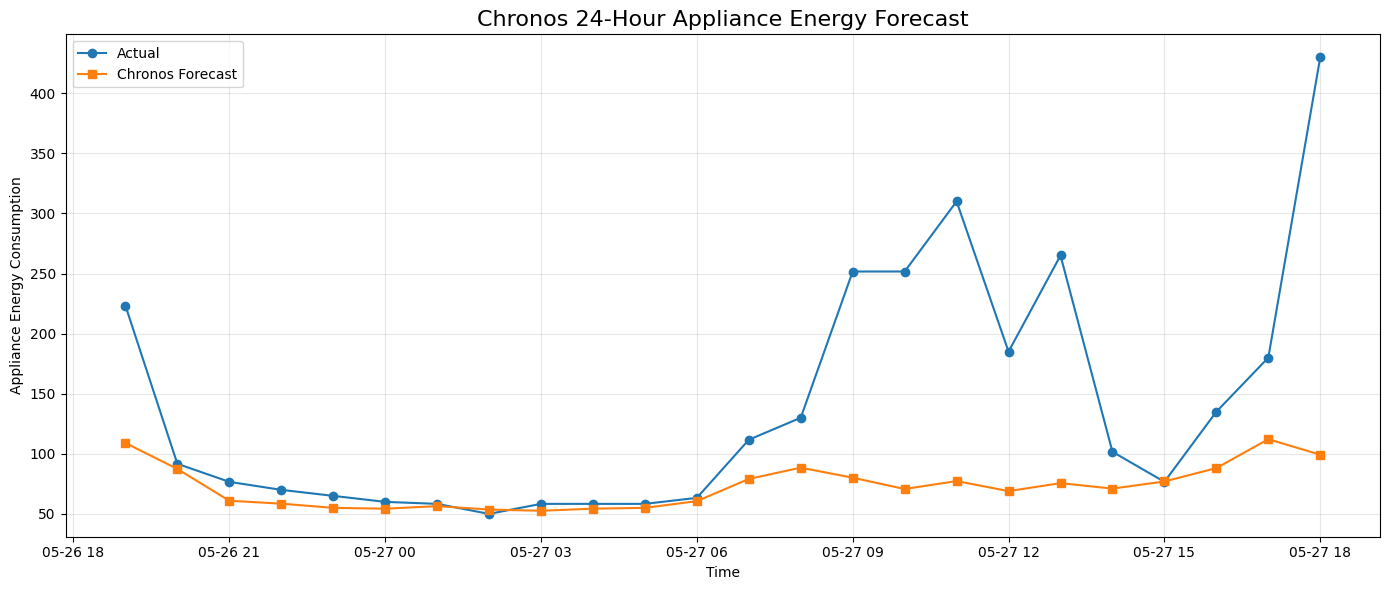

In [12]:
plt.figure(figsize=(14,6))


plt.plot(
    actual.index,
    actual.values,
    marker="o",
    label="Actual"
)


plt.plot(
    actual.index,
    chronos_prediction,
    marker="s",
    label="Chronos Forecast"
)


plt.title(
    "Chronos 24-Hour Appliance Energy Forecast",
    fontsize=16
)


plt.xlabel("Time")

plt.ylabel(
    "Appliance Energy Consumption"
)


plt.grid(alpha=0.3)

plt.legend()

plt.tight_layout()


plt.savefig(
    "../outputs/figures/chronos_forecast.png",
    dpi=300
)


plt.show()

# 10. Chronos Forecast Evaluation

The foundation model performance is evaluated using the same metrics used for SARIMA, SARIMAX and XGBoost.

This enables fair comparison between all forecasting approaches.

In [13]:
mae_chronos = mean_absolute_error(
    actual,
    chronos_prediction
)


rmse_chronos = np.sqrt(
    mean_squared_error(
        actual,
        chronos_prediction
    )
)


mape_chronos = np.mean(
    np.abs(
        (actual.values - chronos_prediction)
        /
        actual.values
    )
) * 100


r2_chronos = r2_score(
    actual,
    chronos_prediction
)



print(f"MAE: {mae_chronos:.2f}")
print(f"RMSE: {rmse_chronos:.2f}")
print(f"MAPE: {mape_chronos:.2f}%")
print(f"R2: {r2_chronos:.3f}")

MAE: 67.67
RMSE: 111.67
MAPE: 31.05%
R2: -0.276


# 11. Saving Chronos Results

The Chronos evaluation results are saved for comparison with all previous forecasting models.

In [14]:
chronos_results = pd.DataFrame({

    "Model":["Chronos-T5-tiny"],

    "MAE":[mae_chronos],

    "RMSE":[rmse_chronos],

    "MAPE":[mape_chronos],

    "R2":[r2_chronos]

})


chronos_results

,Model,MAE,RMSE,MAPE,R2
0,Chronos-T5-tiny,67.667953,111.669485,31.048449,-0.276422


In [15]:
chronos_results.to_csv(
    "../outputs/tables/chronos_results.csv",
    index=False
)


print("Chronos results saved")

Chronos results saved
